##  Regresión Multivariada
### Selección de variables predictoras

Dr. Hugo García Tecocoatzi

Vamos a generar datos sintéticos para la actividad:

In [ ]:
!pip install --upgrade --force-reinstall numpy pandas

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

%matplotlib inline

In [10]:

data= pd.read_csv("Realestate.csv")
data.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [11]:
data = data.drop(columns=['No'])
data.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [12]:

data = data.rename(columns={
    'X1 transaction date': 'Fecha_transaccion',
    'X2 house age': 'Antiguedad',
    'X3 distance to the nearest MRT station': 'Distancia_MRT',
    'X4 number of convenience stores': 'Tiendas_conveniencia',
    'X5 latitude': 'Latitud',
    'X6 longitude': 'Longitud',
    'Y house price of unit area': 'Precio'
})



print(f"Forma del dataset: {data.shape}")
print("\nPrimeras 5 filas:")
df.head()

Forma del dataset: (414, 7)

Primeras 5 filas:


,Tamaño,Habitaciones,Antigüedad,Ubicación,Precio
0,54.967142,56.040504,12.027862,7.270966,2883.606365
1,48.617357,50.299711,17.003125,2.233504,2375.107469
2,56.476885,59.726039,20.026218,7.608818,2880.673545
3,65.230299,68.391705,20.234903,9.066914,3243.647454
4,47.658466,43.525458,17.749673,6.240305,2367.830477


In [14]:
# Estadísticas descriptivas
print("ESTADÍSTICAS DESCRIPTIVAS\n")
print(data.describe().round(2))

ESTADÍSTICAS DESCRIPTIVAS

       Fecha_transaccion  Antiguedad  Distancia_MRT  Tiendas_conveniencia  \
count             414.00      414.00         414.00                414.00   
mean             2013.15       17.71        1083.89                  4.09   
std                 0.28       11.39        1262.11                  2.95   
min              2012.67        0.00          23.38                  0.00   
25%              2012.92        9.02         289.32                  1.00   
50%              2013.17       16.10         492.23                  4.00   
75%              2013.42       28.15        1454.28                  6.00   
max              2013.58       43.80        6488.02                 10.00   

       Latitud  Longitud  Precio  
count   414.00    414.00  414.00  
mean     24.97    121.53   37.98  
std       0.01      0.02   13.61  
min      24.93    121.47    7.60  
25%      24.96    121.53   27.70  
50%      24.97    121.54   38.45  
75%      24.98    121.54   46.60  

In [13]:
# Matriz de correlación detallada
print("\nMATRIZ DE CORRELACIÓN\n")
print(data.corr().round(3))


MATRIZ DE CORRELACIÓN

                      Fecha_transaccion  Antiguedad  Distancia_MRT  \
Fecha_transaccion                 1.000       0.018          0.061   
Antiguedad                        0.018       1.000          0.026   
Distancia_MRT                     0.061       0.026          1.000   
Tiendas_conveniencia              0.010       0.050         -0.603   
Latitud                           0.035       0.054         -0.591   
Longitud                         -0.041      -0.049         -0.806   
Precio                            0.087      -0.211         -0.674   

                      Tiendas_conveniencia  Latitud  Longitud  Precio  
Fecha_transaccion                    0.010    0.035    -0.041   0.087  
Antiguedad                           0.050    0.054    -0.049  -0.211  
Distancia_MRT                       -0.603   -0.591    -0.806  -0.674  
Tiendas_conveniencia                 1.000    0.444     0.449   0.571  
Latitud                              0.444    1.000    

### Preguntas

1. ¿Qué variables tienen mayor correlación con el Precio?

utiliazndo de base esto:Precio:0.087, -0.211,       -0.674, 0.571, 0.546, 0.523, 1.000. Las variables con mayor correción en orden son:
   
     1.   Distancia_MRT : -0.674
     2.   Tiendas_conveniencia : 0.571


2. ¿Hay variables altamente correlacionadas entre sí? ¿Cuáles?

Utilizando en VIF y estos indicarores, podemos decir que no hay una multicolinealidad severa.

- VIF > 5: indica alta multicolinealidad
- VIF > 10: indica multicolinealidad severa

La variable que más se acerca es Distancia_MRT con:   4.323019

3. ¿Cómo crees que afecta cada variable al precio?
- Distancia_MRT: mientras más lejos está una vivienda del metro, más baja su precio (negativo).
- Tiendas_conveniencia: con más tiendas cercanas sube el precio (positiva).
- Antigüedad: casas más viejas valen menos (negativa).
- Latitud: diferencia de precio entre las zonas, a mejor zona, mayor precio (positivo).
- Fecha_transaccion: prqueño aumento de precio con el tiempo dentro del periodo muestreado.
- Longitud: no aporta información significativa.


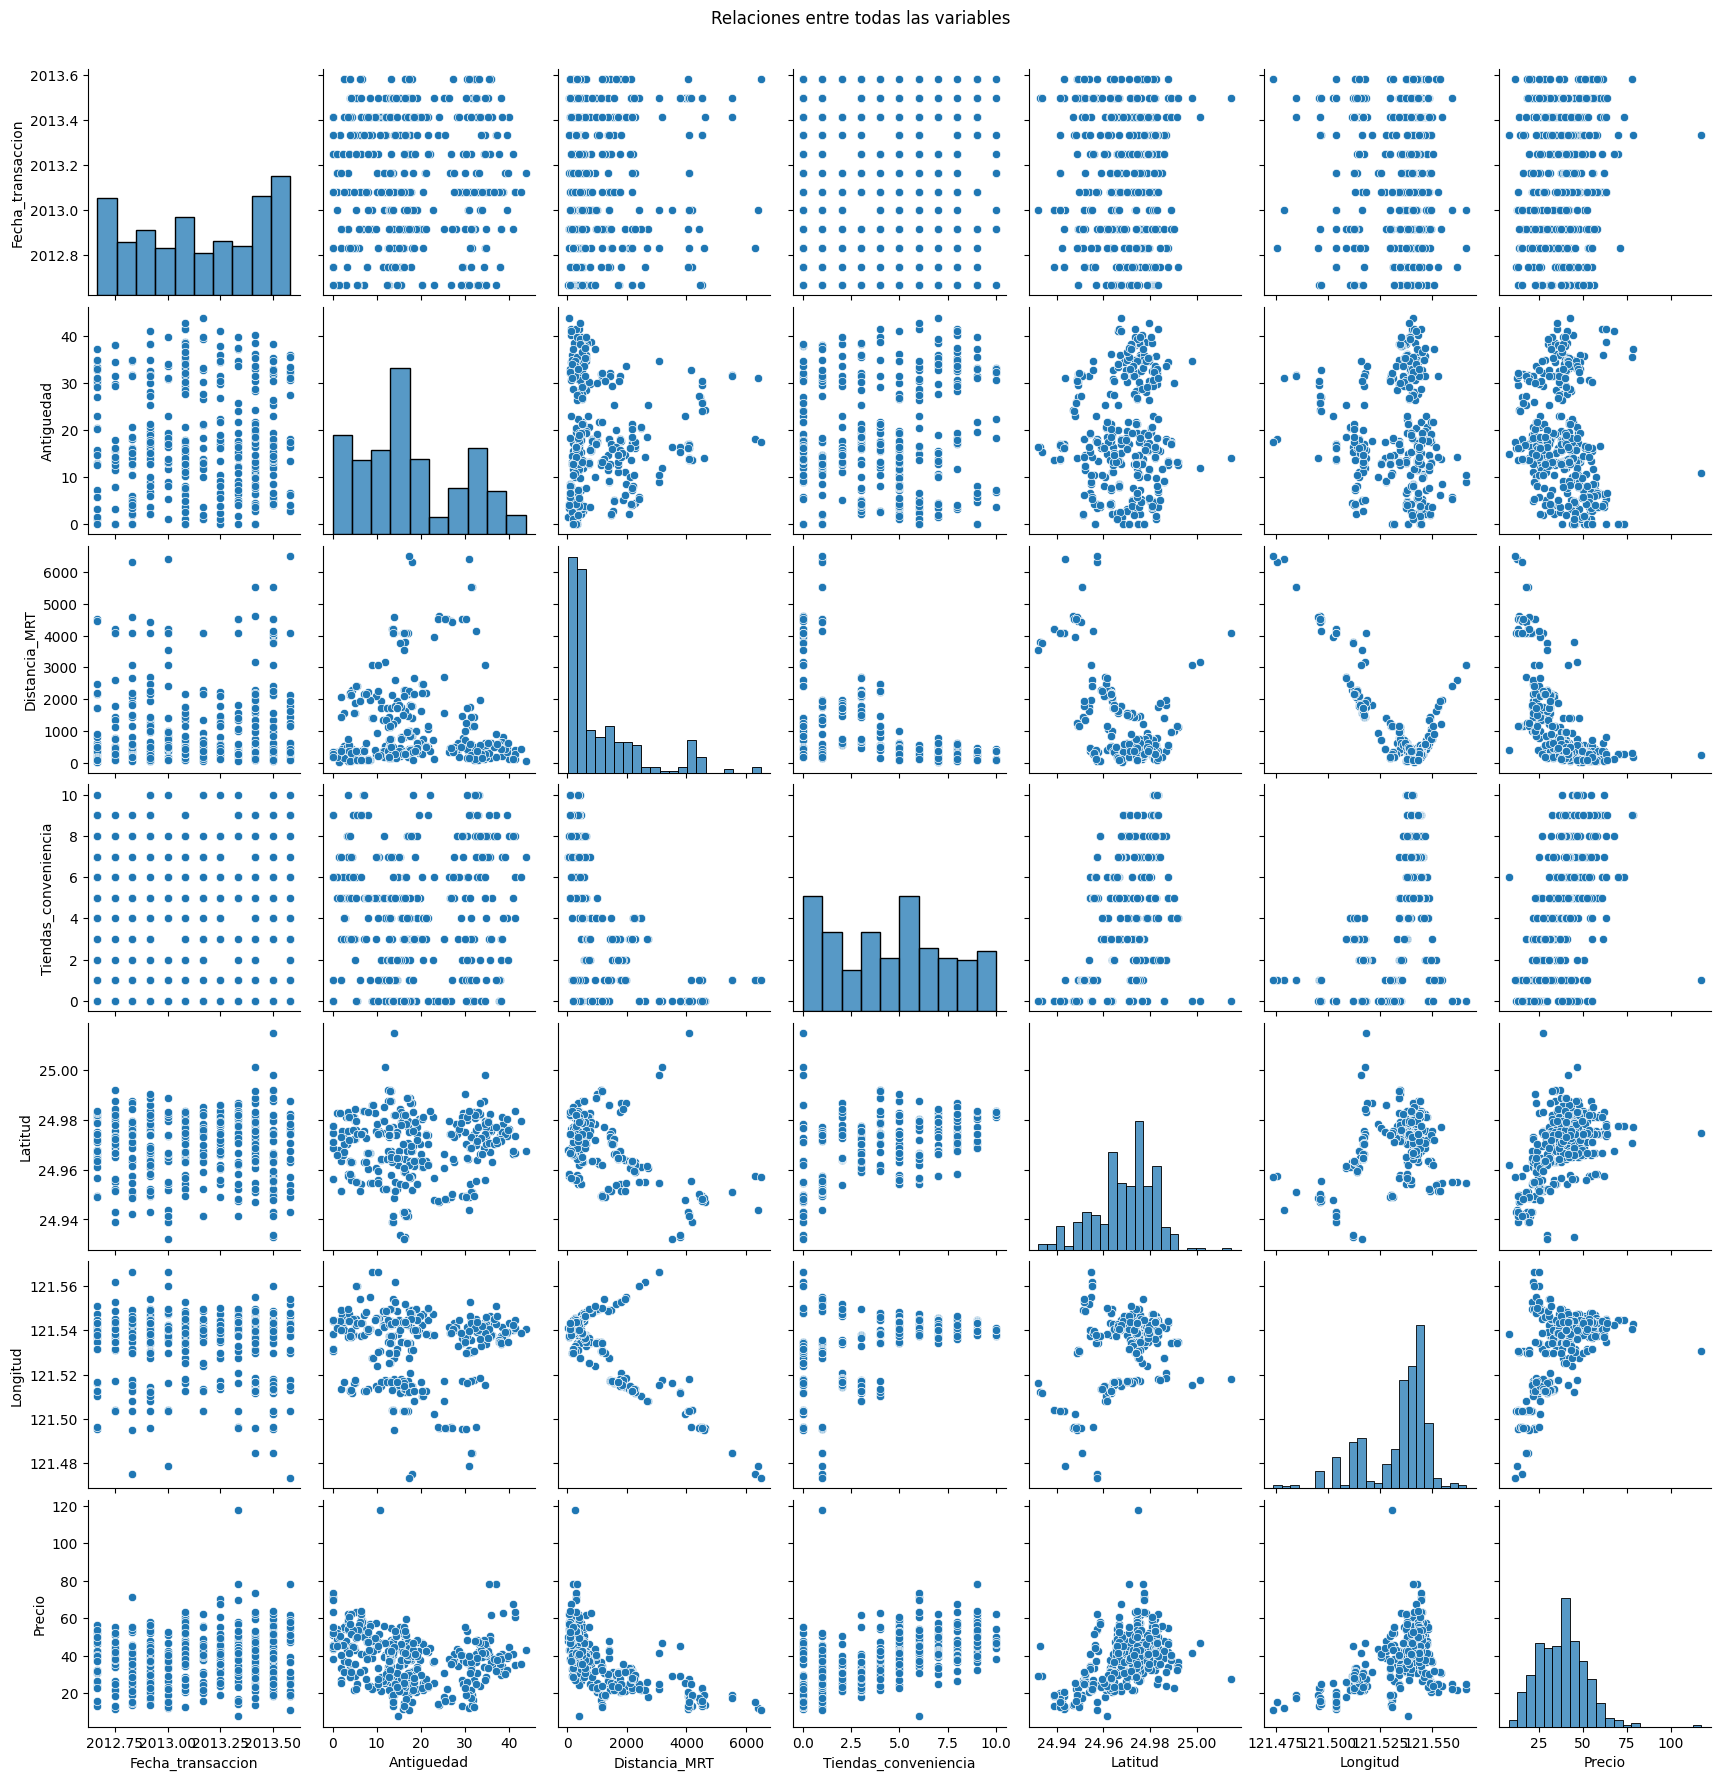

In [15]:
# Pairplot de variables
sns.pairplot(data)
plt.suptitle('Relaciones entre todas las variables', y=1.02)
plt.show()

In [16]:
#  Dividir datos en entrenamiento y prueba
X = data.drop('Precio', axis=1)
y = data['Precio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Tamaño de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño de prueba: {X_test.shape[0]} muestras")

Tamaño de entrenamiento: 289 muestras
Tamaño de prueba: 125 muestras


In [17]:
# Entrenar modelo de regresión lineal con todas las variables
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Mostrar coeficientes
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})
print("=== COEFICIENTES DEL MODELO ===\n")
print(coeficientes)
print(f"\nIntercept (término constante): {modelo.intercept_:.4f}")

=== COEFICIENTES DEL MODELO ===

               Variable  Coeficiente
0     Fecha_transaccion     5.847797
1            Antiguedad    -0.242546
2         Distancia_MRT    -0.005139
3  Tiendas_conveniencia     1.074495
4               Latitud   239.096949
5              Longitud   -52.235159

Intercept (término constante): -11350.7405


In [18]:
# Evaluar modelo completo
y_pred = modelo.predict(X_test)

MAE = metrics.mean_absolute_error(y_test, y_pred)
MSE = metrics.mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = metrics.r2_score(y_test, y_pred)

print("=== MÉTRICAS DE EVALUACIÓN ===\n")
print(f"Error Absoluto Medio (MAE): {MAE:.4f}")
print(f"Error Cuadrático Medio (MSE): {MSE:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {RMSE:.4f}")
print(f"R² (Coeficiente de Determinación): {R2:.4f}")

=== MÉTRICAS DE EVALUACIÓN ===

Error Absoluto Medio (MAE): 6.1848
Error Cuadrático Medio (MSE): 73.5684
Raíz del Error Cuadrático Medio (RMSE): 8.5772
R² (Coeficiente de Determinación): 0.5601


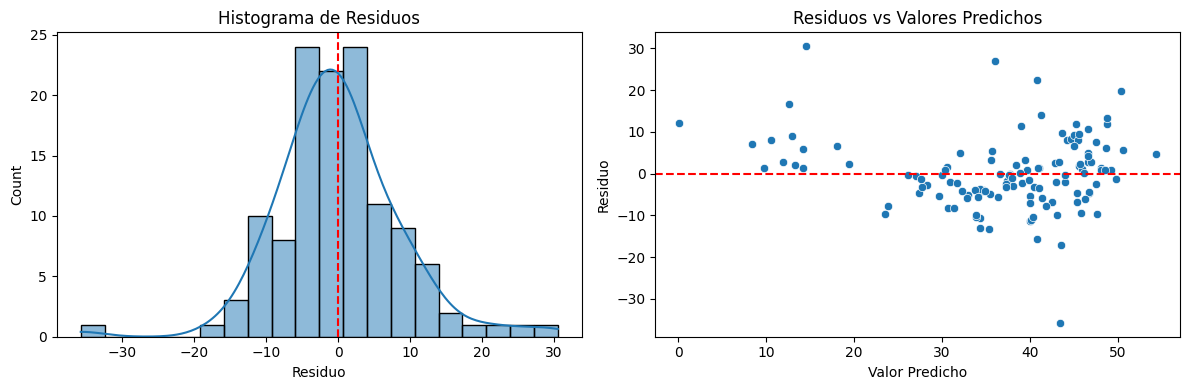

Media de residuos: -0.0122
Desviación estándar de residuos: 8.6117


In [19]:
# Análisis de residuos
residuos = y_test - y_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(residuos, kde=True, bins=20)
plt.axvline(x=0, color='r', linestyle='--')
plt.title('Histograma de Residuos')
plt.xlabel('Residuo')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred, y=residuos)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuos vs Valores Predichos')
plt.xlabel('Valor Predicho')
plt.ylabel('Residuo')

plt.tight_layout()
plt.show()

print(f"Media de residuos: {residuos.mean():.4f}")
print(f"Desviación estándar de residuos: {residuos.std():.4f}")

In [20]:
# Cálculo del VIF (Factor de Inflación de la Varianza)
X_constant = sm.add_constant(X)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_constant.columns
vif_data["VIF"] = [variance_inflation_factor(X_constant.values, i)
                   for i in range(X_constant.shape[1])]

print("=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===\n")
print(vif_data)
print("\n Recuerda:")
print("- VIF > 5: indica alta multicolinealidad")
print("- VIF > 10: indica multicolinealidad severa")

=== FACTOR DE INFLACIÓN DE LA VARIANZA (VIF) ===

               Variable       VIF
0                 const  1.000000
1     Fecha_transaccion  1.014674
2            Antiguedad  1.014287
3         Distancia_MRT  4.323019
4  Tiendas_conveniencia  1.617038
5               Latitud  1.610234
6              Longitud  2.926302

 Recuerda:
- VIF > 5: indica alta multicolinealidad
- VIF > 10: indica multicolinealidad severa


In [21]:
#  Selección hacia adelante (Forward Selection)
def forward_selection(X, y, threshold=0.05):
    """
    Selección de variables hacia adelante basada en p-valor
    """
    included = []
    while True:
        changed = False
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype=float)

        for new_col in excluded:
            model = sm.OLS(y, sm.add_constant(pd.DataFrame(X[included + [new_col]]))).fit()
            new_pval[new_col] = model.pvalues[new_col]

        best_pval = new_pval.min()
        if best_pval < threshold:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True

        if not changed:
            break

    return included

print("=== SELECCIÓN HACIA ADELANTE ===\n")
variables_seleccionadas = forward_selection(X, y)
print(f"Variables seleccionadas: {variables_seleccionadas}")

=== SELECCIÓN HACIA ADELANTE ===

Variables seleccionadas: ['Distancia_MRT', 'Tiendas_conveniencia', 'Antiguedad', 'Latitud', 'Fecha_transaccion']


In [23]:
# Comparación de modelos con diferentes variables
print("=== COMPARACIÓN DE MODELOS ===\n")

combinaciones = [
    ['Distancia_MRT'],
    ['Distancia_MRT', 'Tiendas_conveniencia'],
    ['Distancia_MRT', 'Tiendas_conveniencia', 'Antiguedad'],
    list(X.columns),
    variables_seleccionadas
]

nombres_combinaciones = [
    'Modelo 1: Distancia_MRT',
    'Modelo 2: Distancia_MRT + Tiendas_conveniencia',
    'Modelo 3: Distancia_MRT + Tiendas_conveniencia + Antiguedad',
    'Modelo 4: Modelo completo (todas las variables)',
    'Modelo 5: Variables seleccionadas (Forward)'
]

for nombre, vars_list in zip(nombres_combinaciones, combinaciones):
    X_sel = sm.add_constant(X[vars_list])
    model = sm.OLS(y, X_sel).fit()

    print(f"📊 {nombre}")
    print(f"  Variables: {vars_list}")
    print(f"  R² = {model.rsquared:.4f}")
    print(f"  R² ajustado = {model.rsquared_adj:.4f}")
    print(f"  AIC = {model.aic:.2f}")
    print(f"  BIC = {model.bic:.2f}")
    print()

=== COMPARACIÓN DE MODELOS ===

📊 Modelo 1: Distancia_MRT
  Variables: ['Distancia_MRT']
  R² = 0.4538
  R² ajustado = 0.4524
  AIC = 3089.07
  BIC = 3097.12

📊 Modelo 2: Distancia_MRT + Tiendas_conveniencia
  Variables: ['Distancia_MRT', 'Tiendas_conveniencia']
  R² = 0.4966
  R² ajustado = 0.4941
  AIC = 3057.28
  BIC = 3069.36

📊 Modelo 3: Distancia_MRT + Tiendas_conveniencia + Antiguedad
  Variables: ['Distancia_MRT', 'Tiendas_conveniencia', 'Antiguedad']
  R² = 0.5411
  R² ajustado = 0.5377
  AIC = 3020.97
  BIC = 3037.08

📊 Modelo 4: Modelo completo (todas las variables)
  Variables: ['Fecha_transaccion', 'Antiguedad', 'Distancia_MRT', 'Tiendas_conveniencia', 'Latitud', 'Longitud']
  R² = 0.5824
  R² ajustado = 0.5762
  AIC = 2987.92
  BIC = 3016.11

📊 Modelo 5: Variables seleccionadas (Forward)
  Variables: ['Distancia_MRT', 'Tiendas_conveniencia', 'Antiguedad', 'Latitud', 'Fecha_transaccion']
  R² = 0.5823
  R² ajustado = 0.5772
  AIC = 2985.99
  BIC = 3010.15



In [24]:
# Análisis detallado del mejor modelo
print("=== MEJOR MODELO SEGÚN FORWARD SELECTION ===\n")

X_sel = sm.add_constant(X[variables_seleccionadas])
modelo_final = sm.OLS(y, X_sel).fit()
print(modelo_final.summary())

=== MEJOR MODELO SEGÚN FORWARD SELECTION ===

                            OLS Regression Results                            
Dep. Variable:                 Precio   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.577
Method:                 Least Squares   F-statistic:                     113.8
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           4.47e-75
Time:                        23:31:28   Log-Likelihood:                -1487.0
No. Observations:                 414   AIC:                             2986.
Df Residuals:                     408   BIC:                             3010.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

In [25]:
# Evaluación del mejor modelo en test
X_train_sel = X_train[variables_seleccionadas]
X_test_sel = X_test[variables_seleccionadas]

modelo_sel = LinearRegression()
modelo_sel.fit(X_train_sel, y_train)

y_pred_sel = modelo_sel.predict(X_test_sel)

MAE_sel = metrics.mean_absolute_error(y_test, y_pred_sel)
MSE_sel = metrics.mean_squared_error(y_test, y_pred_sel)
RMSE_sel = np.sqrt(MSE_sel)
R2_sel = metrics.r2_score(y_test, y_pred_sel)

print("=== COMPARACIÓN DE RENDIMIENTO ===\n")
print("Modelo Completo vs Modelo Seleccionado:")

print(f"\nModelo Completo (todas las variables):")
print(f"  MAE: {MAE:.4f}")
print(f"  RMSE: {RMSE:.4f}")
print(f"  R²: {R2:.4f}")

print(f"\nModelo Seleccionado ({variables_seleccionadas}):")
print(f"  MAE: {MAE_sel:.4f}")
print(f"  RMSE: {RMSE_sel:.4f}")
print(f"  R²: {R2_sel:.4f}")

=== COMPARACIÓN DE RENDIMIENTO ===

Modelo Completo vs Modelo Seleccionado:

Modelo Completo (todas las variables):
  MAE: 6.1848
  RMSE: 8.5772
  R²: 0.5601

Modelo Seleccionado (['Distancia_MRT', 'Tiendas_conveniencia', 'Antiguedad', 'Latitud', 'Fecha_transaccion']):
  MAE: 6.1424
  RMSE: 8.5266
  R²: 0.5652


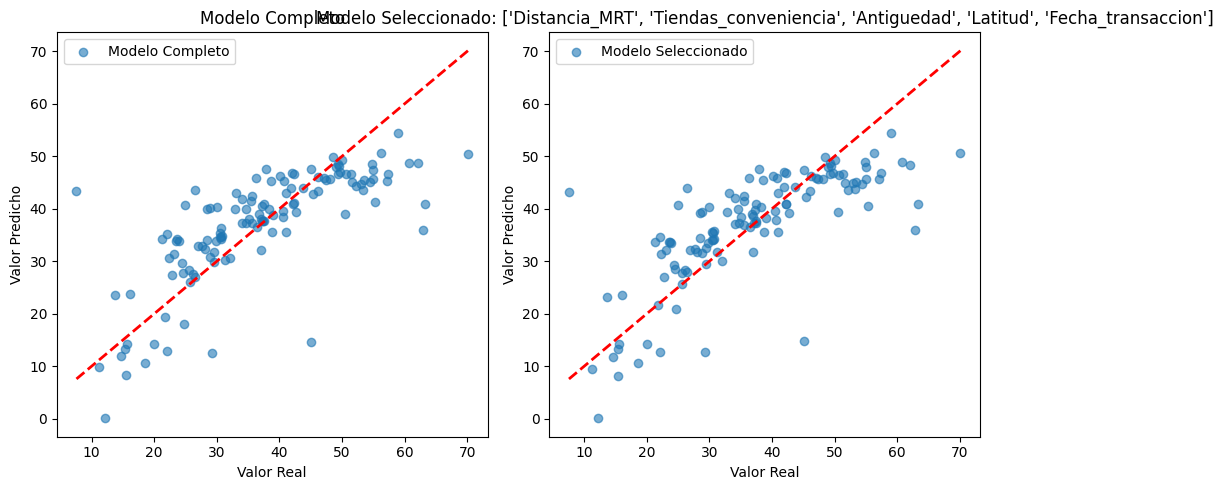

In [26]:
# Visualización del modelo seleccionado
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, label='Modelo Completo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Modelo Completo')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sel, alpha=0.6, label='Modelo Seleccionado')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title(f'Modelo Seleccionado: {variables_seleccionadas}')
plt.legend()

plt.tight_layout()
plt.show()

## Actividad Final

Utiliza este notebook para ver qué varibles debes eliminar de la base de datos de Real Estate

Modelo 5: Variables seleccionadas (Forward)
  Variables: ['Distancia_MRT', 'Tiendas_conveniencia', 'Antiguedad', 'Latitud', 'Fecha_transaccion']

Forward elimina una variable, que es la de "Longitud", la cual nos da estos resultados:
  R² = 0.5823
  R² ajustado = 0.5772
  AIC = 2985.99
  BIC = 3010.15

  Como conclusión, mejora un poco su ajuste y quita una variable que no agrega información relevante.


  

In [3]:
print("FIN, MUCHAS GRACIAS")

FIN, MUCHAS GRACIAS
